# Flow Matching 03: Exponential Decay Cosine Dataset
Author: diego.camarero@estudiante.uam.es

In [ ]:
experiment_number = '03'

kernel_sizes = (21, 17, 9, 9)

dataset_size = 2000

training_epochs = 1000

experiment_name = f"training_flow_{experiment_number}_ExponentialDecayCosine_{dataset_size}"

In [ ]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/notebooks'
%cd "{PROJECT_PATH}"


BASE_DIR = os.path.abspath("..")
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/notebooks

[INFO] Running on device: cuda



In [ ]:
from utils.reproducibility import seed_everything, seed_worker

seed = 42
seed_everything(seed)

In [ ]:
# Jupyter
# %load_ext autoreload
# %autoreload 2

# Standard library
from functools import partial

# Third-party
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

# Project modules
import flow.flow_process as flow

from models.v_model import UNetScoreModel

from data.functional_dataset import (
    ExponentialDecayCosineDataset,
)

from utils.metrics import (
    fit_dataset,
    parametric_model,
    residual_MSE,
    wasserstein_uniform_vs_samples,
    plot_hist_vs_uniform,
    plot_metric_distributions,
    plot_mse_histogram,
    plot_training_evolution,
    plot_loss_history,
)

from utils.checkpoints import (
    save_checkpoint,
    load_checkpoint,
)

from utils.training_plots import (
    plot_function_grid,
    plot_flow_process,
)

## Dataset creation

torch.Size([8, 1, 128])


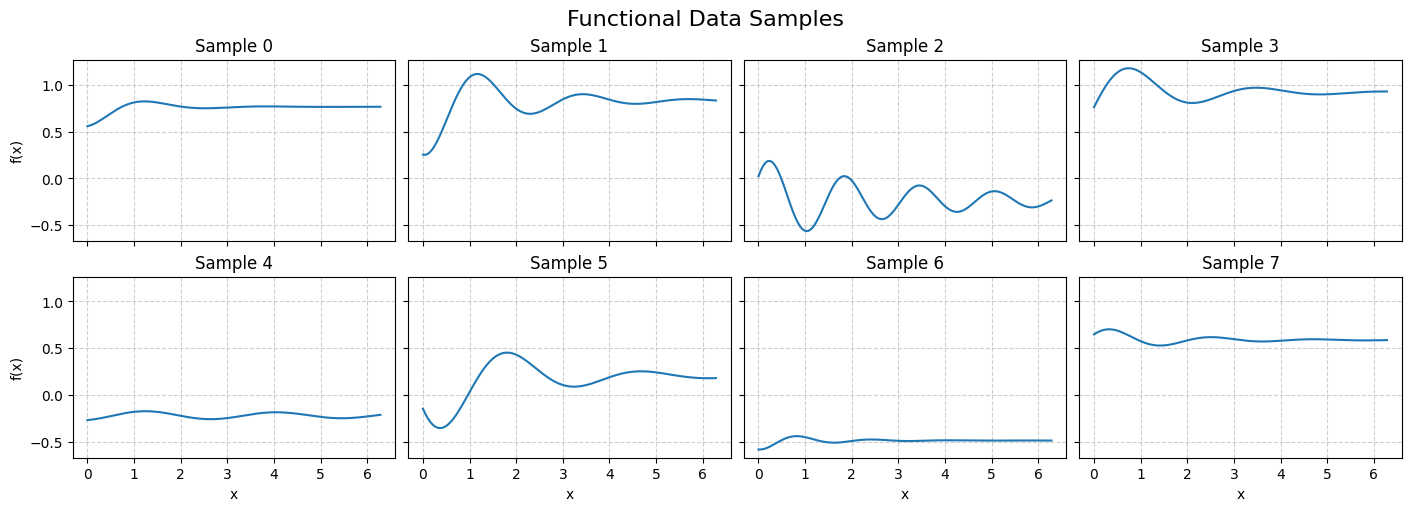

In [ ]:
# Create functional dataset

M = 128
N = dataset_size
x_inf, x_sup = 0.0, 2*torch.pi

a_min, a_max = -1.0, 1.0
b_min, b_max = -1.0, 1.0
alpha_min, alpha_max = 0.1, 1.0
w_min, w_max = 2.0, 4.0
phase_min, phase_max = -torch.pi / 2.0, torch.pi / 2.0

theta_min = [a_min, b_min, alpha_min, w_min, phase_min]
theta_max = [a_max, b_max, alpha_max, w_max, phase_max]

data_train = ExponentialDecayCosineDataset(
    N, n_points=M, x_inf=x_inf, x_sup=x_sup, seed=seed,
    a_min=a_min, a_max=a_max, b_min=b_min, b_max=b_max, alpha_min=alpha_min, alpha_max=alpha_max,
    w_min=w_min, w_max=w_max, phase_min=phase_min, phase_max=phase_max,
)

# Plot some examples of the dataset
n_examples = 8
examples = torch.stack([data_train[i] for i in range(n_examples)])
print(examples.shape)

plot_function_grid(
    examples,
    n_plots=n_examples,
    axis_x = data_train.axis_x,
)

## Flow Matching process

In [ ]:
def alpha_t(t):
    return 1 - t

def diff_alpha_t(t):
    return -1

def beta_t(t):
    return t

def diff_beta_t(t):
    return 1

t_0 = 0.0
T = 1.0
t_eps = 0.0
flow_process = flow.FlowMatchingProcess(
    alpha_t=alpha_t,
    beta_t=beta_t,
    diff_alpha_t=diff_alpha_t,
    diff_beta_t=diff_beta_t,
    t_end=T,
    t_eps=t_eps,
)

torch.Size([3, 100, 1, 128])


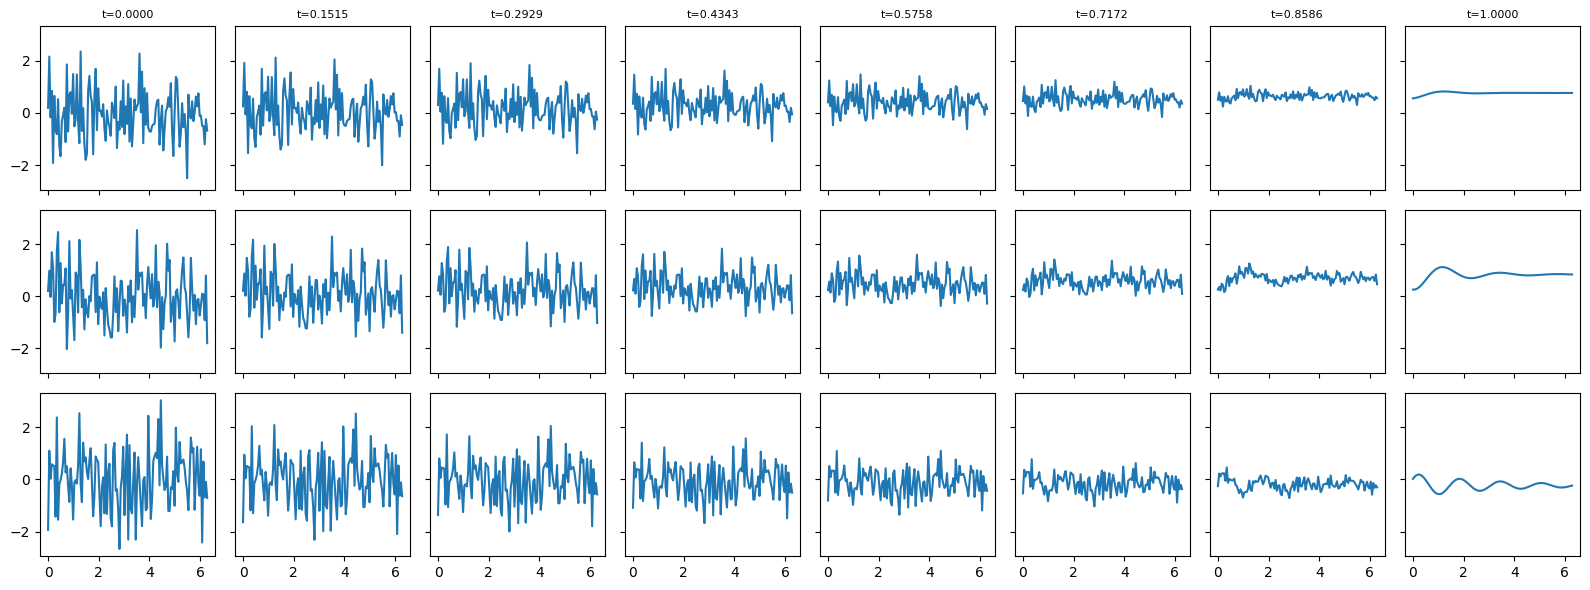

In [ ]:
# Example flow process

n_steps = 100

synthetic_functions_t = flow.flow_interpolation(data_train[:].to(device), alpha_t, beta_t, t_0, T, n_steps)
print(synthetic_functions_t.shape)

plot_flow_process(
    synthetic_functions_t,
    axis_x=data_train.axis_x,
    num_steps=8,
    t_start=t_0,
    t_end=T,
)

## Training

In [ ]:
# Define the model

v_model = UNetScoreModel(
    multiply_inv_sigma=None,
    random_state=seed,
    device=device,
    kernel_sizes=kernel_sizes,
)

learning_rate = 1.0e-3
optimizer = Adam(v_model.parameters(), lr=learning_rate)
n_epochs = training_epochs
save_every = max(1, n_epochs // 10)

  0%|          | 0/1000 [00:00<?, ?it/s]

Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkpoints/training_flow_03_ExponentialDecayCosine_2000/checkpoint_epoch_1.pth
Epoch: 1. Loss: 262.543571. Time: 00:02
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkpoints/training_flow_03_ExponentialDecayCosine_2000/checkpoint_epoch_100.pth
Epoch: 100. Loss: 18.883703. Time: 01:47
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkpoints/training_flow_03_ExponentialDecayCosine_2000/checkpoint_epoch_200.pth
Epoch: 200. Loss: 17.244064. Time: 03:33
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkpoints/training_flow_03_ExponentialDecayCosine_2000/checkpoint_epoch_300.pth
Epoch: 300. Loss: 16.443671. Time: 05:16
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkpoints/training_

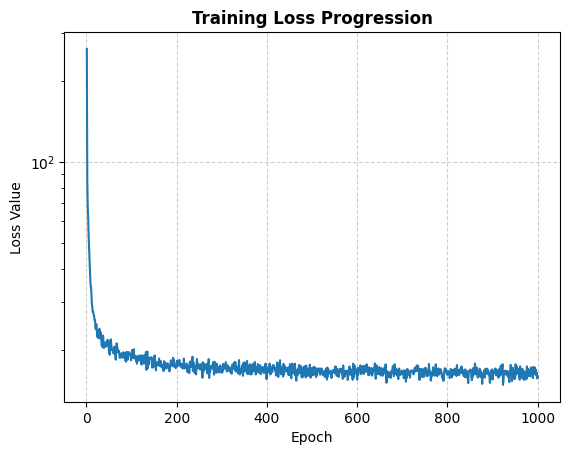

In [ ]:
# Train model

import time
import torchvision.transforms as transforms
import tqdm
from tqdm.notebook import tqdm, trange

batch_size = 32

data_loader = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
)

tqdm_epoch = trange(n_epochs)

loss_history = {
    "epoch": [],
    "loss": []
}

start_time = time.time()
for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0
    for x in data_loader:
        x = x.to(device)
        loss = flow_process.loss_function(v_model, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    elapsed_time = time.time() - start_time
    tqdm_epoch.set_description('Average Loss: {:5f}'.format(epoch_loss))

    loss_history["epoch"].append(epoch + 1)
    loss_history["loss"].append(epoch_loss)

    if epoch == 0 or (epoch + 1) % save_every == 0:
        save_checkpoint(
            epoch=epoch,
            model=v_model,
            optimizer=optimizer,
            loss=epoch_loss,
            elapsed_time=elapsed_time,
            experiment_name=experiment_name,
            checkpoints_dir=CHECKPOINTS_DIR,
        )

if n_epochs % save_every != 0:
    save_checkpoint(
        epoch=n_epochs - 1,
        model=v_model,
        optimizer=optimizer,
        loss=epoch_loss,
        elapsed_time=elapsed_time,
        experiment_name=experiment_name,
        checkpoints_dir=CHECKPOINTS_DIR,
    )

plot_loss_history(loss_history)

## Synthetic data generation

In [ ]:
# Compute results

results = []

saved_epochs = list(range(save_every, n_epochs + 1, save_every))
saved_epochs = [1] + saved_epochs

checkpoint_paths = [
    os.path.join(
        CHECKPOINTS_DIR,
        experiment_name,
        f"checkpoint_epoch_{epoch}.pth"
    )
    for epoch in saved_epochs
]

def ode(x_t, t, v_model):
    v = v_model(x_t, t)
    return v

n_functions = 2000
torch.manual_seed(seed)
x_0 = torch.randn(n_functions, 1, M, device=device)

n_steps = 100
t_0 = 0.0

for ckpt_path in checkpoint_paths:

    v_model, optimizer, epoch, loss, elapsed_time = load_checkpoint(ckpt_path, v_model, optimizer)
    v_model.eval()

    torch.manual_seed(seed)

    with torch.no_grad():
        times, synthetic_functions_t = flow.euler_integrator(
            x_initial=x_0,
            t_start=t_0,
            t_end=T,
            n_times=n_steps,
            ode_coefficient=partial(ode, v_model=v_model)
        )

    synthetic_functions = synthetic_functions_t[:, -1, :, :]

    theta_hat, mse_fit = fit_dataset(
        synthetic_functions,
        data_train.axis_x,
        parametric_model,
    )

    residual_mses = residual_MSE(synthetic_functions, theta_hat, data_train.axis_x, parametric_model)

    wd = {}
    names = ["a", "b", "alpha", "w", "phase"]
    for j, name in enumerate(names):
        wd[name] = wasserstein_uniform_vs_samples(
            samples=theta_hat[:, j],
            a=theta_min[j],
            b=theta_max[j],
        )

    results.append({
        "epoch": epoch,
        "mse": residual_mses.mean().item(),
        "wd_a": wd["a"].item(),
        "wd_b": wd["b"].item(),
        "wd_alpha": wd["alpha"].item(),
        "wd_w": wd["w"].item(),
        "wd_phase": wd["phase"].item(),
    })

Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkpoints/training_flow_03_ExponentialDecayCosine_2000/checkpoint_epoch_1.pth
Epoch: 1. Loss: 262.543571. Time: 00:02
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkpoints/training_flow_03_ExponentialDecayCosine_2000/checkpoint_epoch_100.pth
Epoch: 100. Loss: 18.883703. Time: 01:47
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkpoints/training_flow_03_ExponentialDecayCosine_2000/checkpoint_epoch_200.pth
Epoch: 200. Loss: 17.244064. Time: 03:33
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkpoints/training_flow_03_ExponentialDecayCosine_2000/checkpoint_epoch_300.pth
Epoch: 300. Loss: 16.443671. Time: 05:16
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 2/Flow matching/checkp

## Results

In [ ]:
df = pd.DataFrame(results)
print(df)

    epoch       mse      wd_a      wd_b  wd_alpha      wd_w  wd_phase
0       1  0.110449  0.230309  0.314544  0.592415  0.750018  0.800123
1     100  0.000929  0.197327  0.065535  0.065928  0.053898  0.128001
2     200  0.000322  0.034693  0.148353  0.055513  0.036621  0.194213
3     300  0.000172  0.036422  0.070183  0.048628  0.035280  0.223007
4     400  0.000076  0.056799  0.085212  0.037907  0.043311  0.140242
5     500  0.000088  0.051070  0.080678  0.031883  0.047834  0.128765
6     600  0.000062  0.019588  0.072699  0.034873  0.042330  0.185135
7     700  0.000043  0.075489  0.073996  0.062005  0.045097  0.182041
8     800  0.000044  0.028099  0.067942  0.029501  0.037586  0.143638
9     900  0.000023  0.048370  0.058956  0.067153  0.062645  0.119353
10   1000  0.000023  0.059676  0.060771  0.030990  0.050136  0.167672


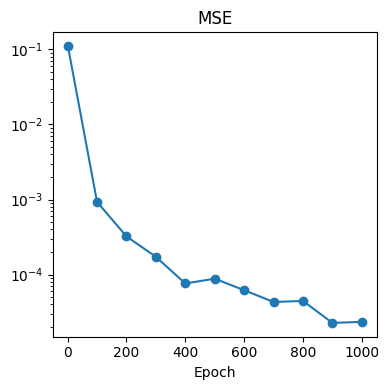

In [ ]:
metrics = ["mse"]
titles = ["MSE"]

plot_training_evolution(df, metrics, titles)

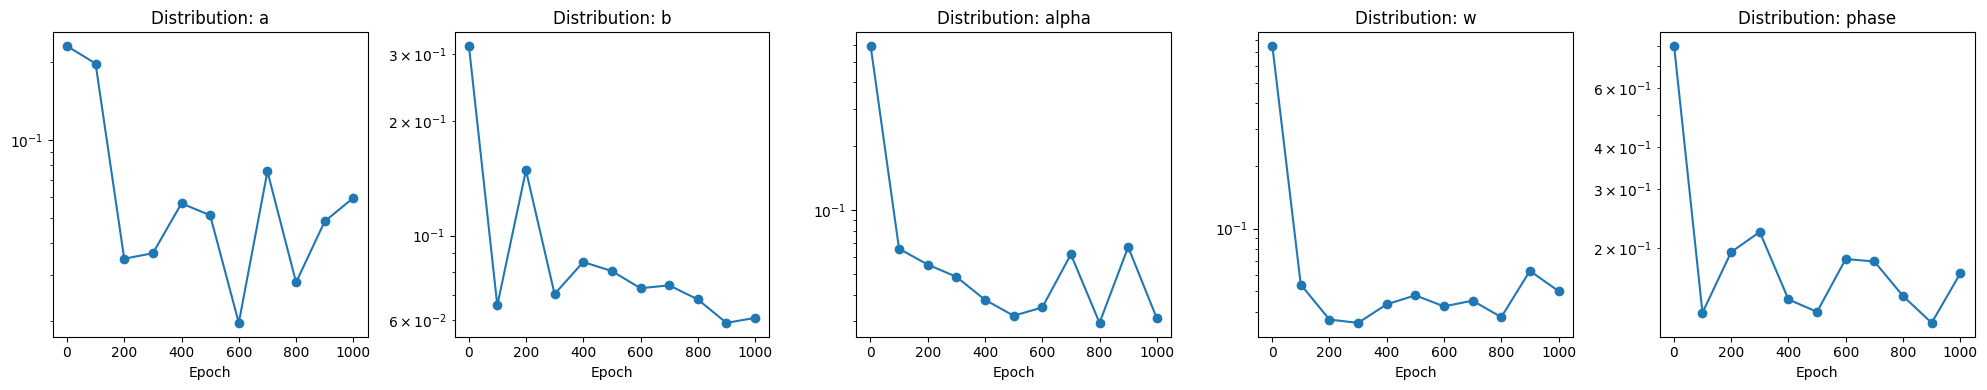

In [ ]:
metrics = ["wd_a", "wd_b", "wd_alpha", "wd_w", "wd_phase"]
titles = ["Distribution: a", "Distribution: b", "Distribution: alpha", "Distribution: w", "Distribution: phase"]

plot_training_evolution(df, metrics, titles)

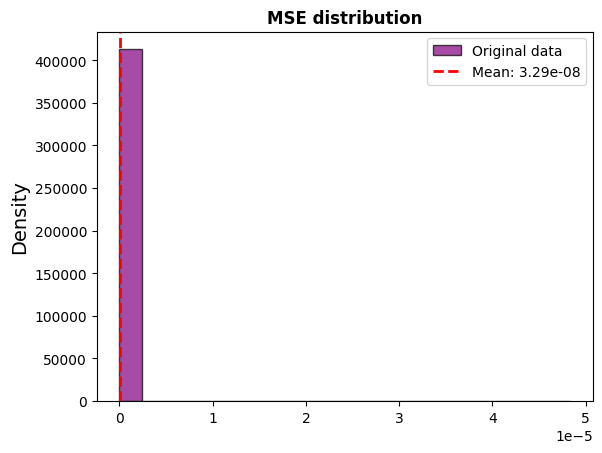

In [ ]:
# original data

data_label = "Original data"

original_theta_hat, original_mse_fit = fit_dataset(
        data_train.data,
        data_train.axis_x,
        parametric_model,
)

# cambiar original_theta_hat por hat_true
hat_true = data_train.parameters

original_mses = residual_MSE(
    data_train.data,
    original_theta_hat,
    # hat_true,
    data_train.axis_x,
    parametric_model,
)

plot_mse_histogram(original_mses, data_label=data_label)

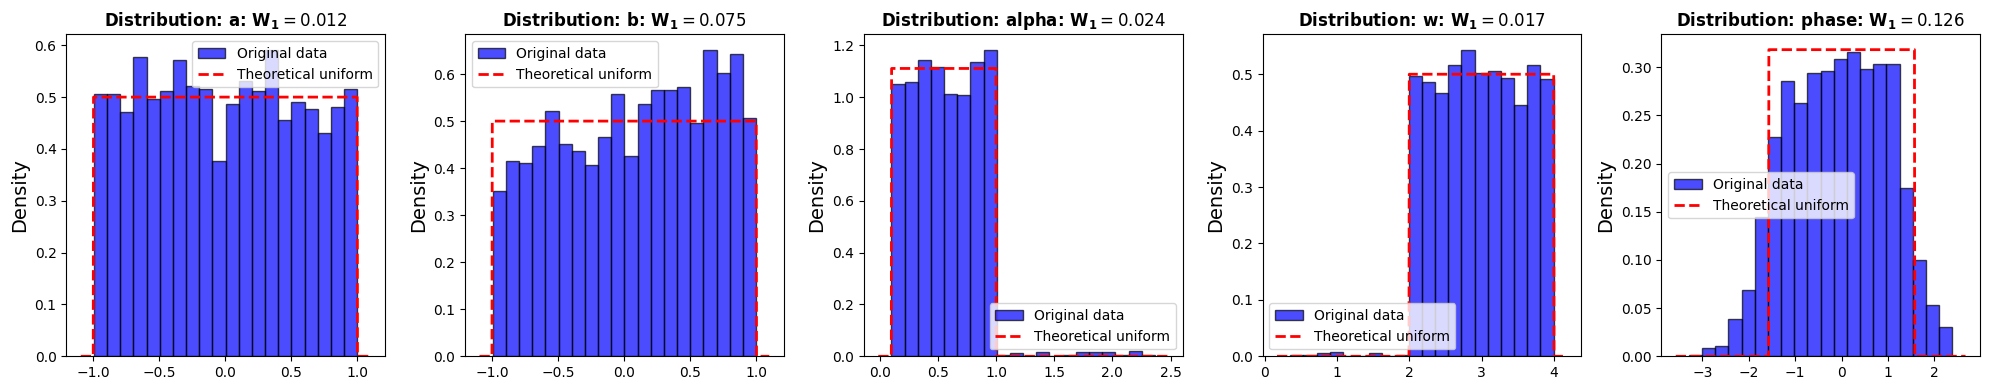

In [ ]:
# original data

# cambiar original_theta_hat por hat_true
hat_true = data_train.parameters

metrics = ["wd_a", "wd_b", "wd_alpha", "wd_w", "wd_phase"]
titles = ["Distribution: a", "Distribution: b", "Distribution: alpha", "Distribution: w", "Distribution: phase"]

plot_metric_distributions(original_theta_hat, theta_min, theta_max, metrics, titles, data_label)

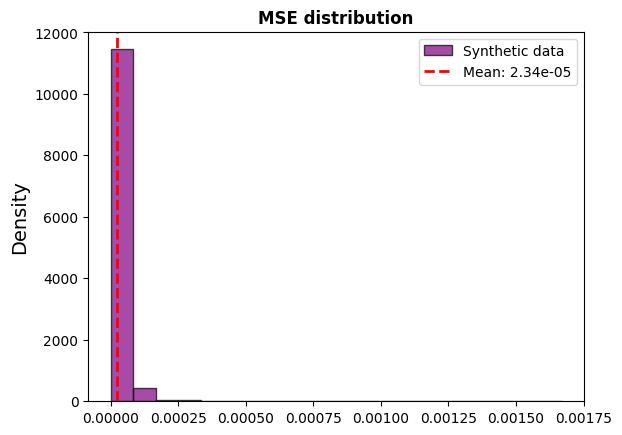

In [ ]:
# synthetic data

data_label = "Synthetic data"

# synthetic data

mses = residual_MSE(
    synthetic_functions,
    theta_hat,
    data_train.axis_x,
    parametric_model,
)

plot_mse_histogram(mses, data_label=data_label)

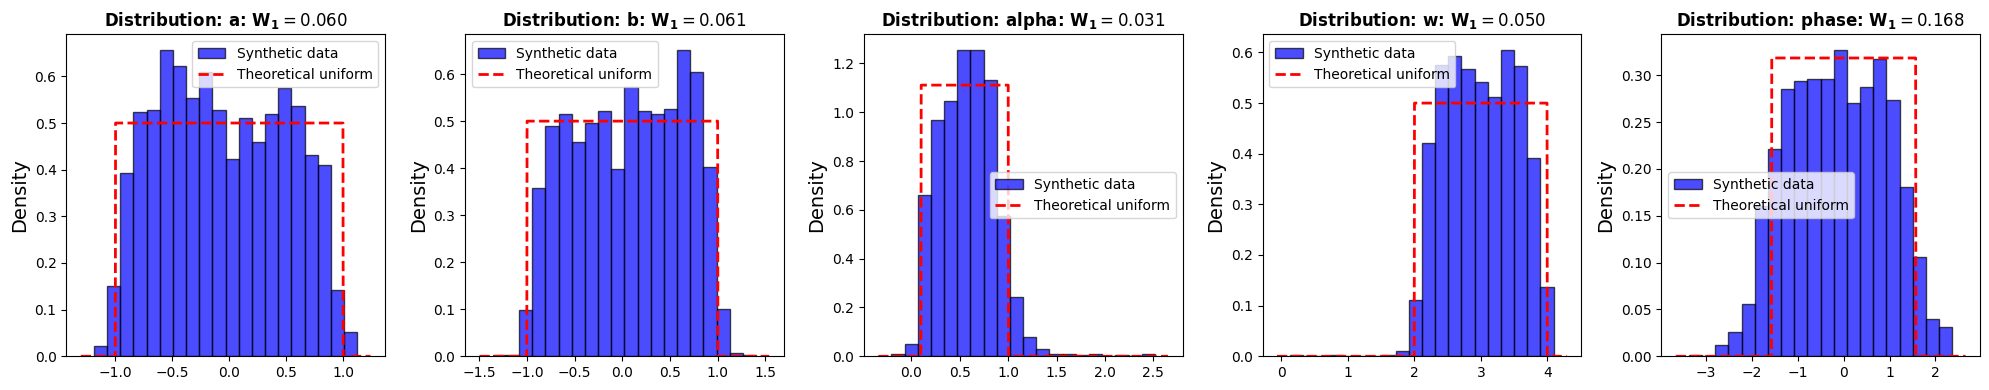

In [ ]:
# synthetic data

metrics = ["wd_a", "wd_b", "wd_alpha", "wd_w", "wd_phase"]
titles = ["Distribution: a", "Distribution: b", "Distribution: alpha", "Distribution: w", "Distribution: phase"]

plot_metric_distributions(theta_hat, theta_min, theta_max, metrics, titles, data_label=data_label)

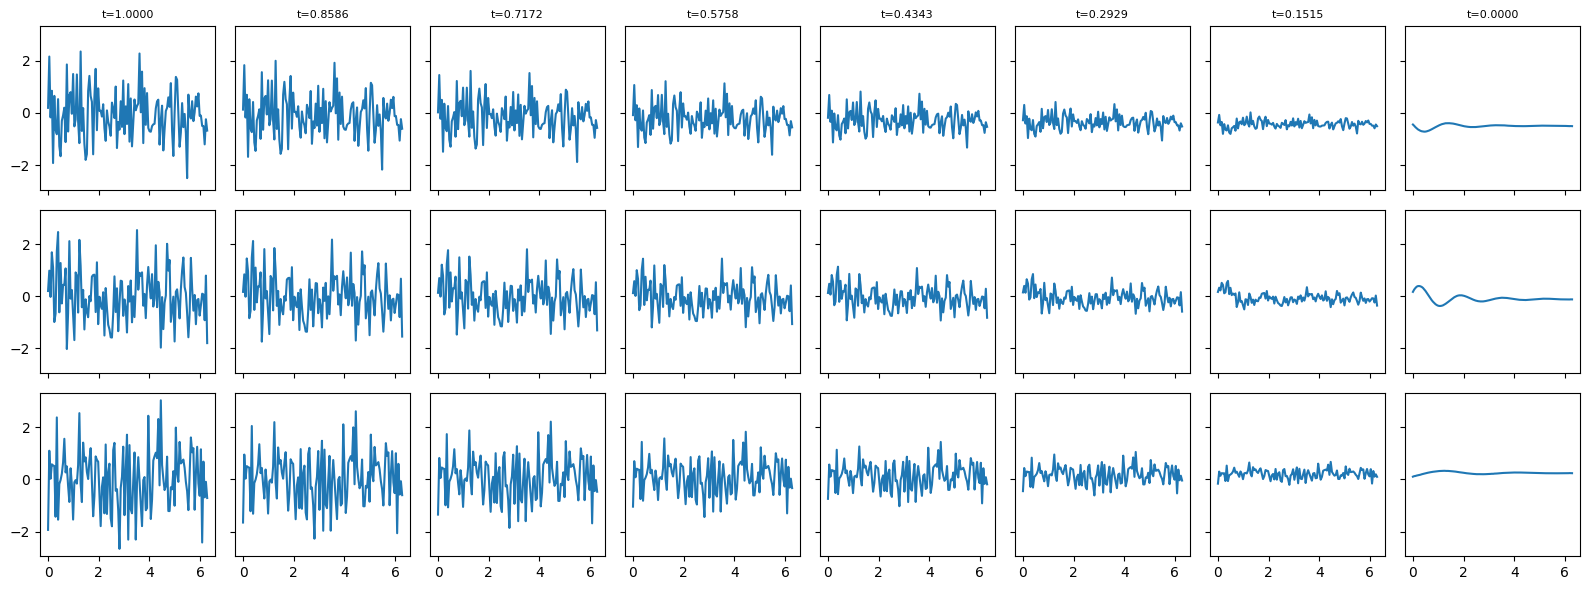

In [ ]:
plot_flow_process(
    synthetic_functions_t,
    data_train.axis_x,
    num_steps=8,
    t_start=T,
    t_end=t_0,
)

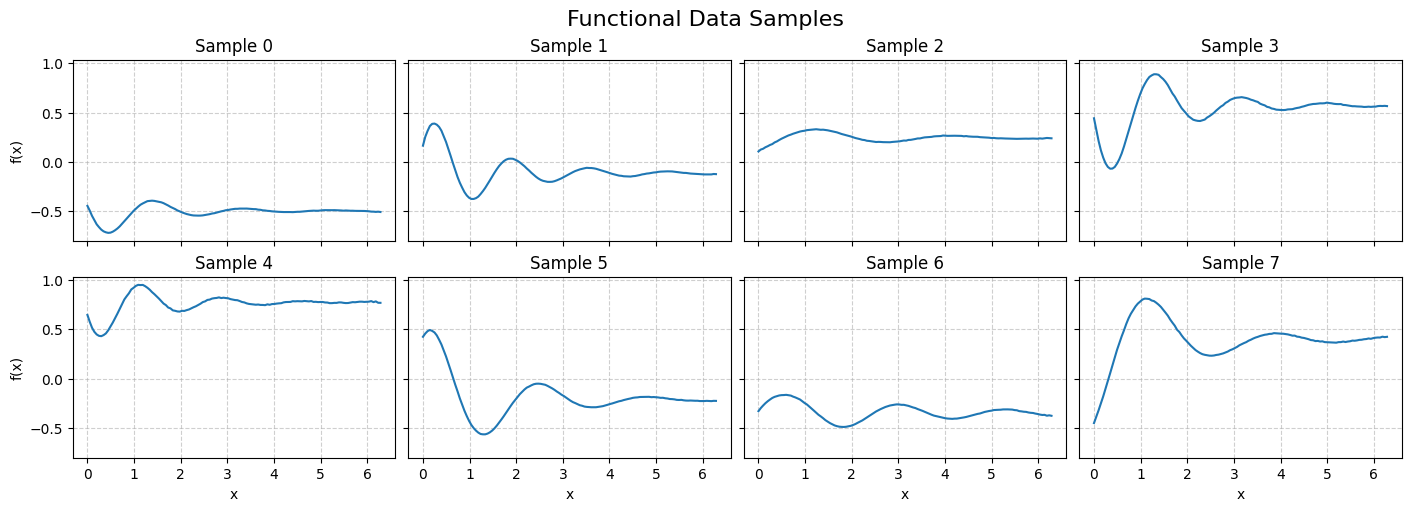

In [ ]:
plot_function_grid(
    synthetic_functions,
    n_plots=8,
    axis_x = data_train.axis_x,
)